# Projeto M1 — Configuração 1 × Configuração 2
**UNIVALI · Processamento de Imagens · Prof. Felipe Viel**
Gustavo Corrêa de Mello · Heloisa Cavalcante Born · João Paulo Jorge Aimi

| Etapa | Configuração 1 ([notebook](config1_pipeline.ipynb)) | Configuração 2 ([notebook](config2_pipeline.ipynb)) |
|---|---|---|
| 1 | ruído Gaussiano σ = 15 | ruído Gaussiano σ = 15 |
| 2 | **equalização** | **mediana 3×3** |
| 3 | **Gaussiano 5×5** | **gama γ = 1,5** |
| 4 | high-boost k = 1,5 | high-boost k = 1,5 |

**Três diferenças:** a ordem (realçar antes × depois de suavizar), a operação pontual e o filtro de suavização.

In [1]:
import sys
sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

# Mesmas configurações de config1_pipeline.ipynb e config2_pipeline.ipynb
CONFIG_1 = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]
CONFIG_2 = [
    ("degradada", lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("suavizada", lambda im: suavizacao.filtro_mediana(im, tamanho=3)),
    ("gama",      lambda im: op.correcao_gama(im, 1.5)),
    ("agucada",   lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]


def estagio(res, nome):
    """Imagem de um estágio da pipeline pelo nome (ex.: 'suavizada')."""
    return dict(res)[nome]


def medir(ref, img):
    return f"PSNR {metricas.psnr(ref, img):5.2f} dB  SSIM {metricas.ssim(ref, img):.3f}"

## 1. Imagens
Três melanomas do tronco posterior (ISIC), cada um com um problema diferente: **contraste baixo**, **pelos densos** e **bordas difusas**.

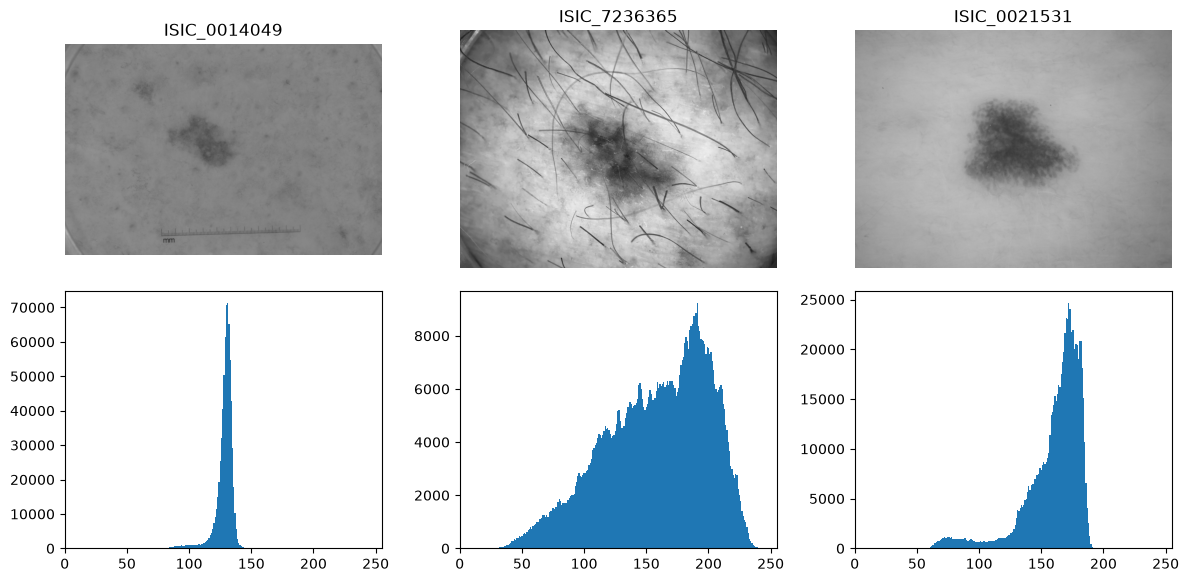

ISIC_0014049: média 128.4   contraste (desvio)   7.4
ISIC_7236365: média 158.4   contraste (desvio)  41.6
ISIC_0021531: média 160.2   contraste (desvio)  23.5


In [2]:
originais = {n: io_utils.carregar_cinza(c, largura_max=1024) for n, c in IMAGENS.items()}
io_utils.mostrar(list(originais.values()), list(originais.keys()))

for n, img in originais.items():
    print(f"{n}: média {img.mean():5.1f}   contraste (desvio) {img.std():5.1f}")

## 2. Rodando as duas configurações
Mesma semente de ruído: as duas partem **da mesma imagem degradada**.

In [3]:
r1 = {n: pipeline.executar(img, CONFIG_1) for n, img in originais.items()}
r2 = {n: pipeline.executar(img, CONFIG_2) for n, img in originais.items()}

## 3. Diferença 1 — a ordem: realçar antes ou depois de suavizar
O que cada configuração faz **logo depois do ruído**.

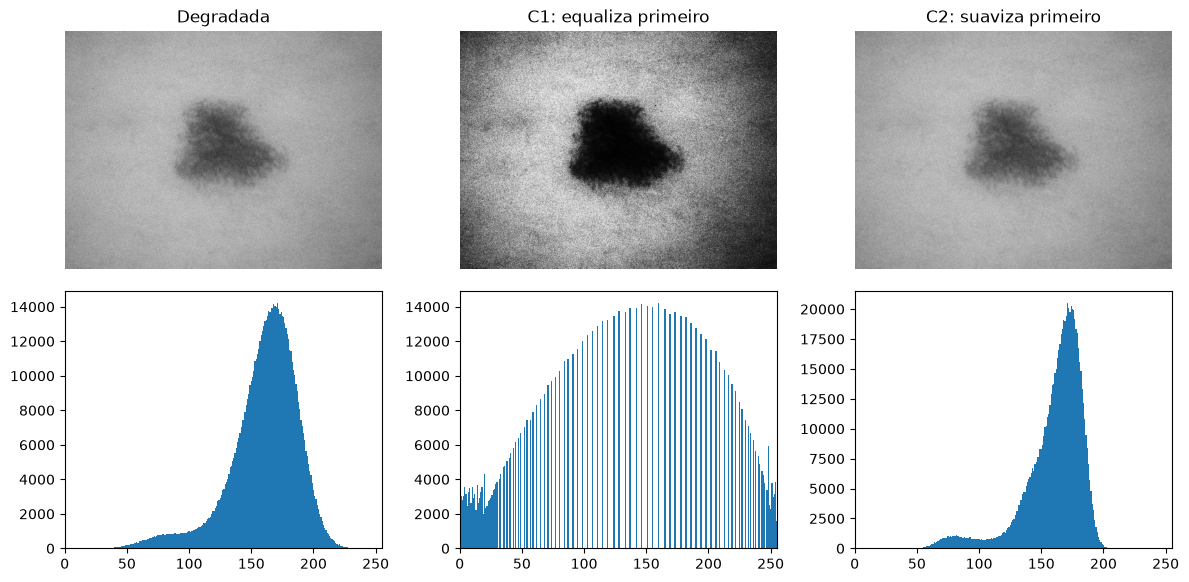

ISIC_0014049   C1 equalizada: PSNR 11.08 dB  SSIM 0.022   |   C2 suavizada: PSNR 32.22 dB  SSIM 0.664


ISIC_7236365   C1 equalizada: PSNR 14.32 dB  SSIM 0.227   |   C2 suavizada: PSNR 30.87 dB  SSIM 0.741


ISIC_0021531   C1 equalizada: PSNR 11.58 dB  SSIM 0.035   |   C2 suavizada: PSNR 32.31 dB  SSIM 0.662


In [4]:
n = "ISIC_0021531"
io_utils.mostrar(
    [estagio(r1[n], "degradada"), estagio(r1[n], "equalizada"), estagio(r2[n], "suavizada")],
    ["Degradada", "C1: equaliza primeiro", "C2: suaviza primeiro"],
)

for n, img in originais.items():
    print(f"{n}   C1 equalizada: {medir(img, estagio(r1[n], 'equalizada'))}   |   C2 suavizada: {medir(img, estagio(r2[n], 'suavizada'))}")

**Conclusão:** equalizar uma imagem ruidosa estica o ruído junto com o contraste (SSIM cai para 0,02–0,23).
Suavizar primeiro mantém o SSIM entre 0,66 e 0,74. **A ordem é a diferença que mais pesa.**

## 4. Diferença 2 — operação pontual: equalização × gama
Aplicadas na original, para isolar o efeito.

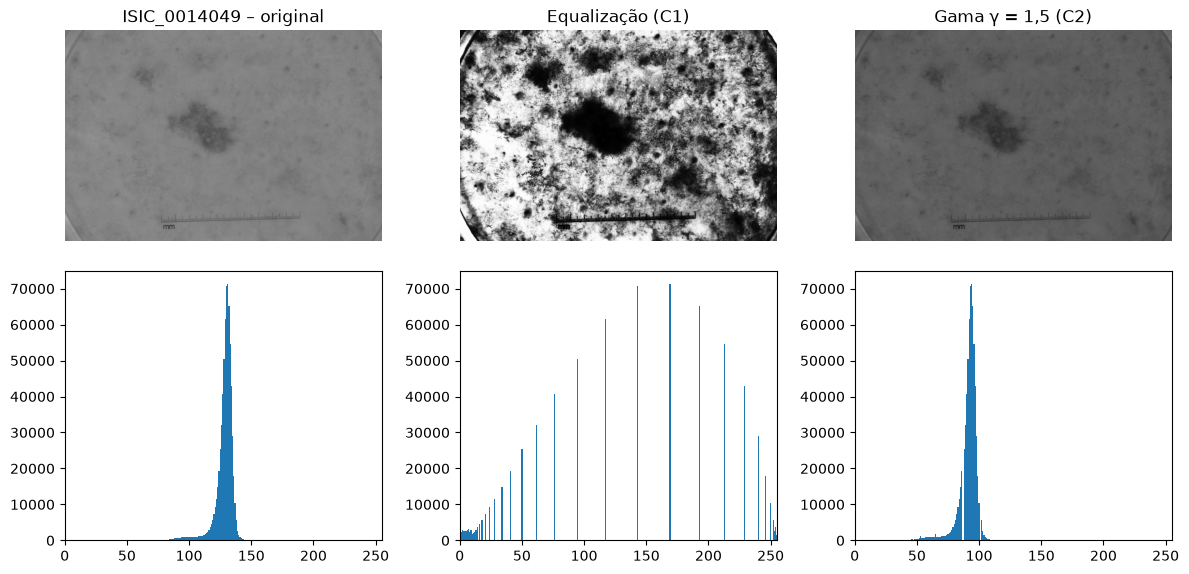

ISIC_0014049   contraste: original   7.4 | equalizada  75.0 | gama   7.6
ISIC_7236365   contraste: original  41.6 | equalizada  73.8 | gama  47.3


ISIC_0021531   contraste: original  23.5 | equalizada  74.4 | gama  25.8


In [5]:
n = "ISIC_0014049"
img = originais[n]
io_utils.mostrar(
    [img, op.equalizar_histograma(img), op.correcao_gama(img, 1.5)],
    [f"{n} – original", "Equalização (C1)", "Gama γ = 1,5 (C2)"],
)

for n, img in originais.items():
    eq, gm = op.equalizar_histograma(img), op.correcao_gama(img, 1.5)
    print(f"{n}   contraste: original {img.std():5.1f} | equalizada {eq.std():5.1f} | gama {gm.std():5.1f}")

**Conclusão:** a equalização multiplica o contraste (até 10×), mas é agressiva e deixa o histograma "em pente".
O gama é suave e previsível, porém quase não ajuda a imagem de contraste mais baixo.

## 5. Diferença 3 — suavização: Gaussiano × mediana
Os dois filtros aplicados na **mesma** imagem degradada.

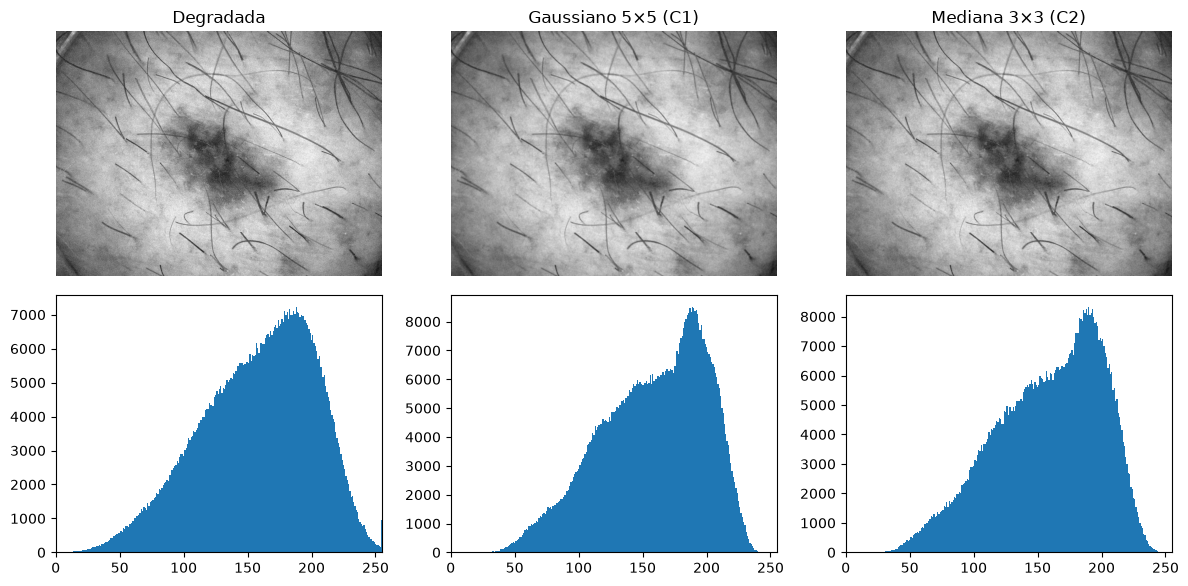

ISIC_0014049   Gaussiano: PSNR 35.09 dB  SSIM 0.802   |   Mediana: PSNR 32.22 dB  SSIM 0.664


ISIC_7236365   Gaussiano: PSNR 31.71 dB  SSIM 0.834   |   Mediana: PSNR 30.87 dB  SSIM 0.741


ISIC_0021531   Gaussiano: PSNR 35.27 dB  SSIM 0.803   |   Mediana: PSNR 32.31 dB  SSIM 0.662


In [6]:
n = "ISIC_7236365"
deg = estagio(r1[n], "degradada")
io_utils.mostrar(
    [deg, suavizacao.filtro_gaussiano(deg, tamanho=5, sigma=1.0), estagio(r2[n], "suavizada")],
    ["Degradada", "Gaussiano 5×5 (C1)", "Mediana 3×3 (C2)"],
)

for n, img in originais.items():
    deg = estagio(r1[n], "degradada")
    gauss = suavizacao.filtro_gaussiano(deg, tamanho=5, sigma=1.0)
    print(f"{n}   Gaussiano: {medir(img, gauss)}   |   Mediana: {medir(img, estagio(r2[n], 'suavizada'))}")

**Conclusão:** isolado, o **Gaussiano vence nas 3 imagens** (≈ 3 dB a mais e SSIM ≈ 0,80 contra 0,66–0,74).
Faz sentido: o ruído inserido é Gaussiano, e a mediana é o filtro indicado para ruído impulsivo (sal e pimenta).
Ou seja, a configuração 2 vence **apesar** do filtro — a vantagem dela vem da **ordem**.

## 6. Aguçamento (igual nas duas)
O enunciado não aceita um resultado só de bordas: o high-boost soma o detalhe à imagem inteira.

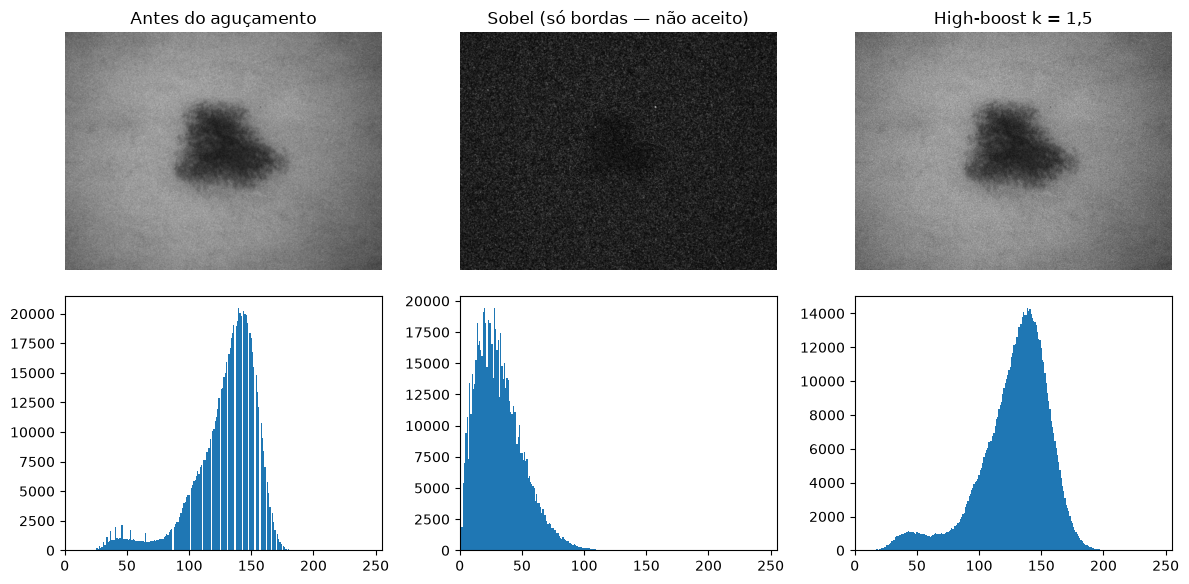

In [7]:
n = "ISIC_0021531"
base = estagio(r2[n], "gama")
io_utils.mostrar(
    [base, agucamento.sobel_edges(base), estagio(r2[n], "agucada")],
    ["Antes do aguçamento", "Sobel (só bordas — não aceito)", "High-boost k = 1,5"],
)

**Conclusão:** o high-boost realça o contorno da lesão, mas também o ruído que sobrou — o SSIM cai nesta etapa
nas duas configurações.

## 7. Resultado final lado a lado

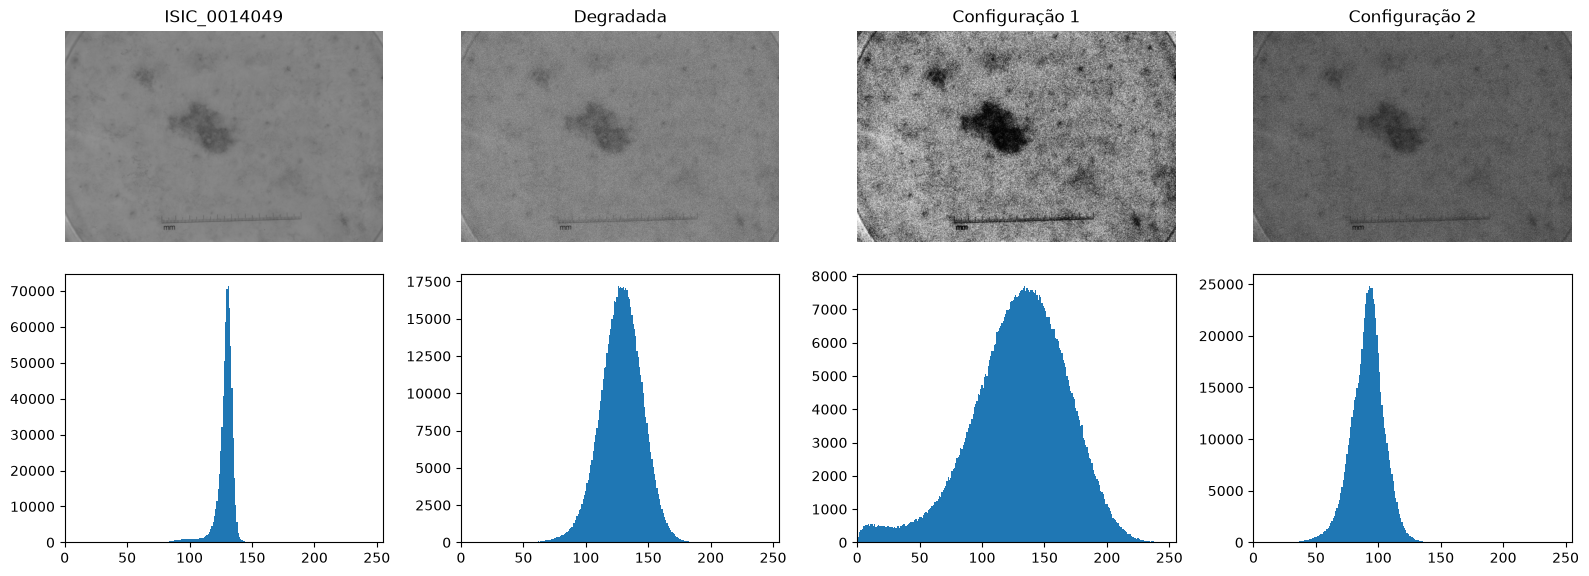

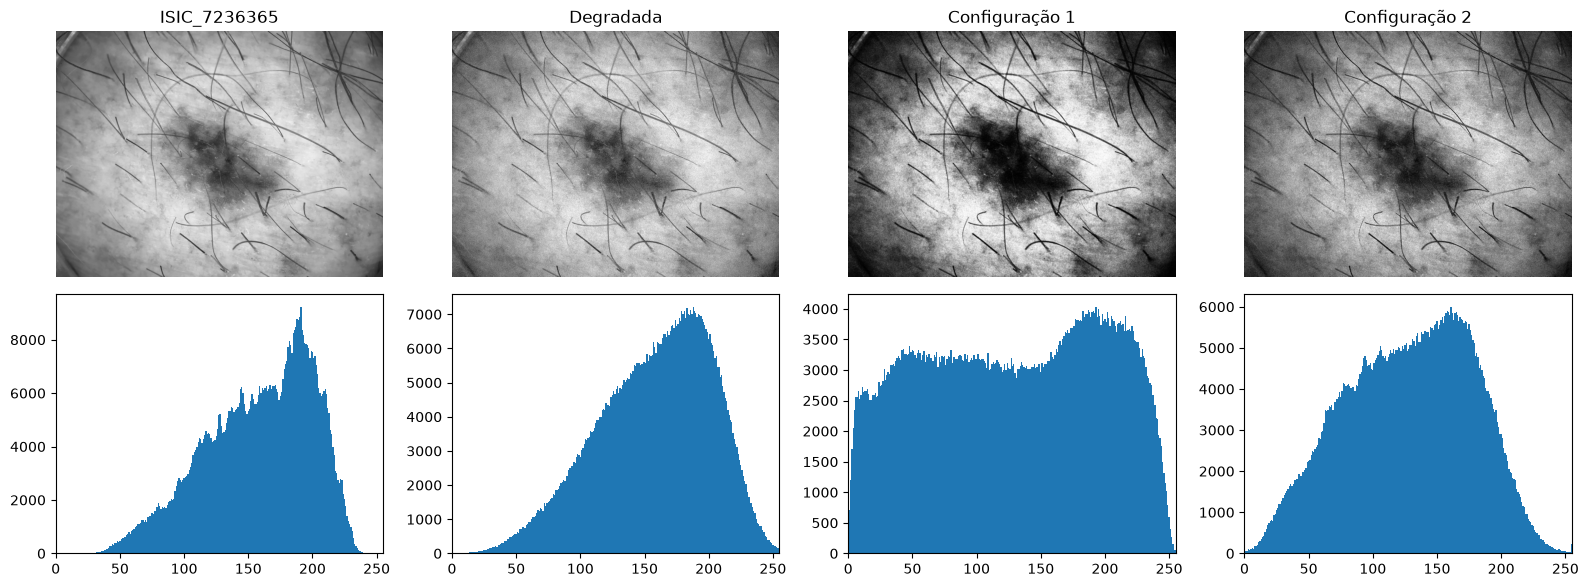

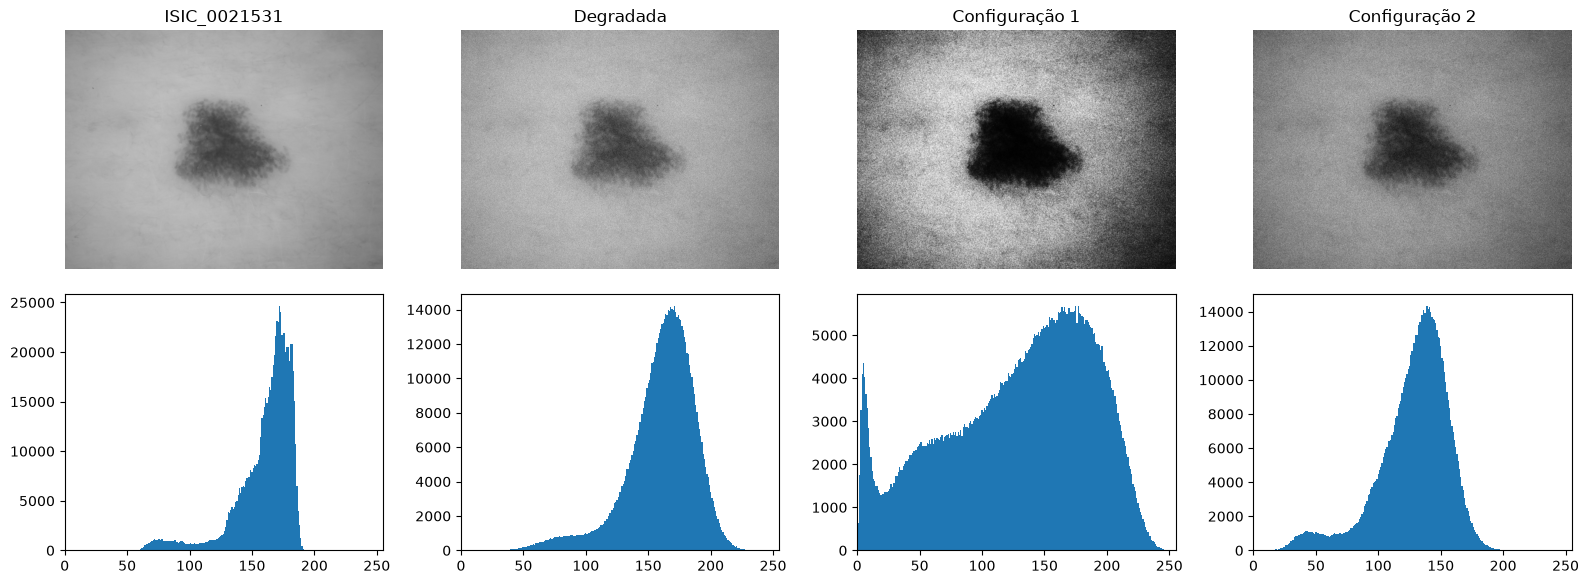

In [8]:
for n, img in originais.items():
    f1, f2 = pipeline.final(r1[n]), pipeline.final(r2[n])
    io_utils.mostrar([img, estagio(r1[n], "degradada"), f1, f2], [n, "Degradada", "Configuração 1", "Configuração 2"])

    io_utils.salvar(estagio(r1[n], "degradada"), f"../resultados/{n}_degradada.png")
    io_utils.salvar(f1, f"../resultados/{n}_config1.png")
    io_utils.salvar(f2, f"../resultados/{n}_config2.png")

## 8. Métricas finais
PSNR mede erro de intensidade (remoção de ruído); SSIM mede preservação de estrutura. Referência: original sem ruído.

In [9]:
print(f"{'Imagem':<14}{'':<6}{'Degradada':>10}{'Config 1':>10}{'Config 2':>10}   Vence")
for n, img in originais.items():
    deg, f1, f2 = estagio(r1[n], "degradada"), pipeline.final(r1[n]), pipeline.final(r2[n])
    for nome_m, f in [("PSNR", metricas.psnr), ("SSIM", metricas.ssim)]:
        v = [f(img, x) for x in (deg, f1, f2)]
        vence = "C1" if v[1] > v[2] else "C2"
        print(f"{n if nome_m == 'PSNR' else '':<14}{nome_m:<6}{v[0]:>10.3f}{v[1]:>10.3f}{v[2]:>10.3f}   {vence}")

Imagem               Degradada  Config 1  Config 2   Vence
ISIC_0014049  PSNR      24.603    17.514    16.366   C1


              SSIM       0.240     0.119     0.357   C2
ISIC_7236365  PSNR      24.612    15.517    17.569   C2


              SSIM       0.401     0.513     0.464   C1
ISIC_0021531  PSNR      24.604    14.098    17.375   C2


              SSIM       0.232     0.168     0.320   C2


## 9. Veredito

| Imagem | Melhor | Por quê |
|---|---|---|
| ISIC_0014049 (contraste baixo) | **nenhuma** | C1 revela a lesão mas com muito ruído; C2 é limpa mas quase sem ganho de contraste |
| ISIC_7236365 (pelos) | **C2** | menor erro; C1 escurece ainda mais os pelos |
| ISIC_0021531 (bordas difusas) | **C2** | melhor PSNR e SSIM; C1 granula o fundo e escurece os cantos |
| ISIC_0112420 (escura, teste) | **C1** | γ = 1,5 escurece demais; a equalização revela a lesão |

- **Suavizar antes de realçar** foi a decisão que mais melhorou o resultado.
- **A combinação ideal ficou de fora:** Gaussiano (melhor filtro) na posição da configuração 2 (suavizar primeiro).
- **Nenhum parâmetro fixo serve para todas:** o γ deveria depender do brilho da imagem.
- **Limitação:** PSNR/SSIM medem fidelidade à original; operações pontuais sempre as derrubam, mesmo quando a lesão fica mais visível.

## 10. Teste com imagem nova
Troque o caminho e rode: as duas configurações na mesma imagem.

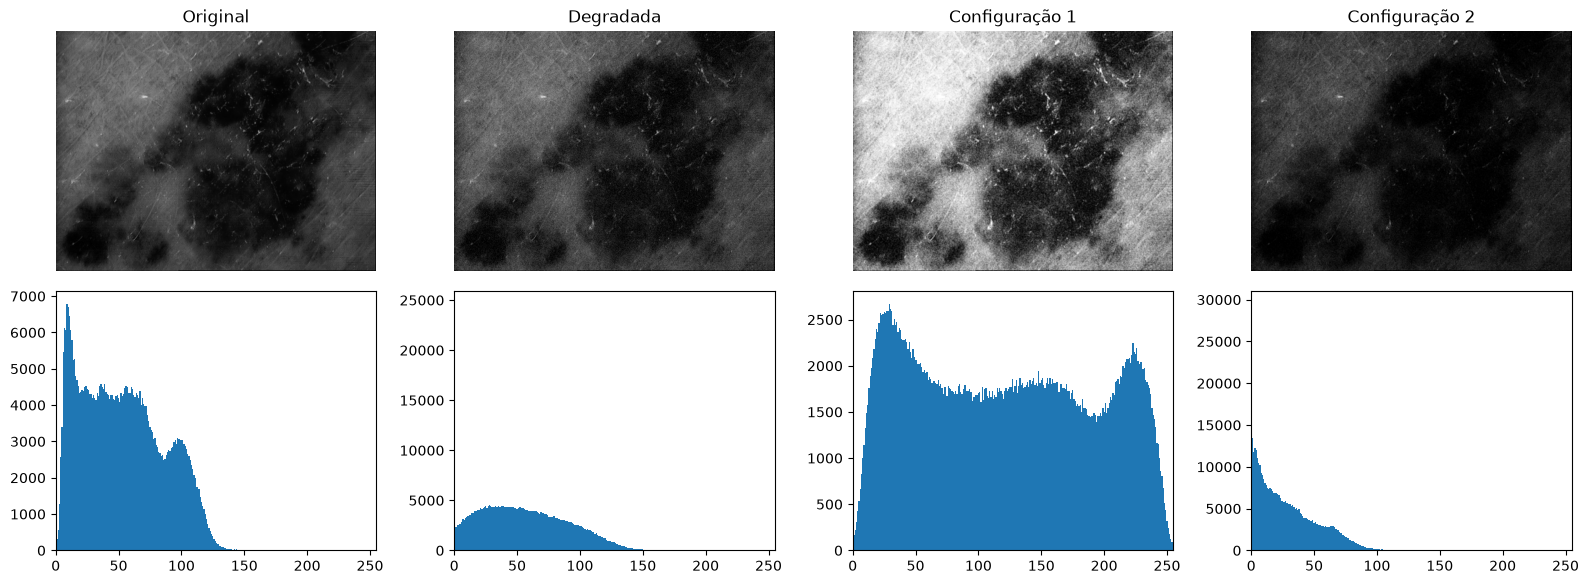

Config 1: PSNR 10.18 dB  SSIM 0.375


Config 2: PSNR 19.01 dB  SSIM 0.459


In [10]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
t1, t2 = pipeline.executar(img, CONFIG_1), pipeline.executar(img, CONFIG_2)
io_utils.mostrar([img, estagio(t1, "degradada"), pipeline.final(t1), pipeline.final(t2)],
                 ["Original", "Degradada", "Configuração 1", "Configuração 2"])
print(f"Config 1: {medir(img, pipeline.final(t1))}")
print(f"Config 2: {medir(img, pipeline.final(t2))}")